In [ ]:
import pandas as pd
import altair as alt
alt.data_transformers.enable('default', max_rows=None)  #renders if the df has more than 5000 rows

DataTransformerRegistry.enable('default')

In [ ]:
alt.__version__

'5.5.0'

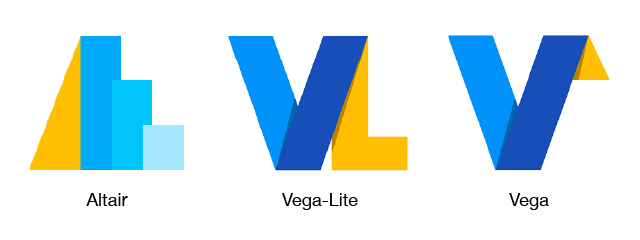

---

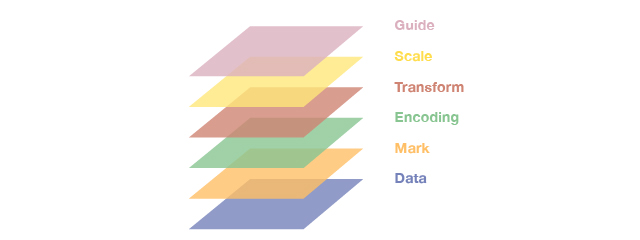

#Data

Tabular Data
- Columns = variables
- Rows = observations

Accepted Formats:
* csv
* json
* url
* data-frame

In [ ]:
df=pd.read_csv('https://raw.githubusercontent.com/danielefadda/dvdj-2022/main/data/gapminder_tidy.csv')

In [ ]:
df.head()

,Country,Year,fertility,life,population,child_mortality,gdp,region
0,Afghanistan,1964,7.671,33.639,10474903.0,339.7,1182.0,South Asia
1,Afghanistan,1965,7.671,34.152,10697983.0,334.1,1182.0,South Asia
2,Afghanistan,1966,7.671,34.662,10927724.0,328.7,1168.0,South Asia
3,Afghanistan,1967,7.671,35.170,11163656.0,323.3,1173.0,South Asia
4,Afghanistan,1968,7.671,35.674,11411022.0,318.1,1187.0,South Asia


* fertility = babies per woman
* child_mortality = Child Mortality Rate (‰), under age five

#Mark


marks are the geometrical objects that we are goignt to plot. They can be of different types:
* mark_area () - Filled areas defined by an upper line and a base line.
* mark_bar () - Rectangular bars.
* mark_circle () - Scatterplot with circles.
* mark_line () - Line segments connected.
* mark_point () - Scatterplot with configurable point shapes.
* mark_rect () - Solid rectangles, useful for heatmaps.
* mark_rule () - A vertical or horizontal line spanning the axis..
* mark_square () - Scatterplot with solid squares.
* mark_text () - A scatter plot with points represented by text.
* mark_tick () - A vertical or horizontal tick mark.

# Encoding

The next steps is to create a link between the marks and the data. The encodings are essential concept in altair visual grammar. Encoding is essentialy a mapping between the visual properties of the mark and the data. Each channels can be mapped over a column in the data to define and enconding.

Today we are goign to see this encoding channels:

* **x**: X position of the mark (X axis).
* **y**: Y position of the mark (Y axis).
* **size**: size of the mark. Can be the area or length, depending on the type of mark.
* **color**: color of the mark, can be specified as a CSS color.
* **opacity**: goes from 0 (completely transparent) to 1.
* **shape**: shape of the points for mark_point.
* **order**: determines the order of the line/area points.




Visualize the Charts as Json object

In [ ]:
alt.Chart(df.head(1)).mark_point().to_dict()

{'config': {'view': {'continuousWidth': 300, 'continuousHeight': 300}},
 'data': {'name': 'data-1b525ee30af9bc1929010834cbf4fe01'},
 'mark': {'type': 'point'},
 '$schema': 'https://vega.github.io/schema/vega-lite/v5.20.1.json',
 'datasets': {'data-1b525ee30af9bc1929010834cbf4fe01': [{'Country': 'Afghanistan',
    'Year': 1964,
    'fertility': 7.671,
    'life': 33.639,
    'population': 10474903.0,
    'child_mortality': 339.7,
    'gdp': 1182.0,
    'region': 'South Asia'}]}}

# Exercises

## Exercise 1
Create a chart that visualize on the *x* axis the fertility index of all the Nations in 2006 . On mouse hover, visualize the tooltip with the fertility and country values

In [ ]:
df_year=df[df['Year']==2006]
df_year

,Country,Year,fertility,life,population,child_mortality,gdp,region
42,Afghanistan,2006,6.702,57.582,28420974.0,116.30,1173.0,South Asia
92,Albania,2006,1.849,76.124,3156607.0,19.50,7476.0,Europe & Central Asia
142,Algeria,2006,2.580,70.020,33391954.0,32.10,12088.0,Middle East & North Africa
192,Angola,2006,6.598,49.041,17010366.0,200.50,5445.0,Sub-Saharan Africa
242,Antigua and Barbuda,2006,2.203,74.729,84952.0,11.80,24016.0,America
...,...,...,...,...,...,...,...,...
9943,Western Sahara,2006,2.633,65.409,461610.0,59.66,NaN,Middle East & North Africa
9993,"Yemen, Rep.",2006,5.199,61.728,21288070.0,NaN,NaN,Middle East & North Africa
10043,Zambia,2006,5.932,48.613,11750105.0,104.60,2752.0,Sub-Saharan Africa
10093,Zimbabwe,2006,3.941,45.157,12529655.0,97.90,1629.0,Sub-Saharan Africa


### Solution A

In [ ]:
alt.Chart(df_year).mark_tick().encode(
    x = alt.X('fertility:Q'),
    tooltip=['fertility:Q','Country:N']
).properties(height=200)

alt.Chart(...)

### Solution B
using filters

In [ ]:
alt.Chart(df).transform_filter(
    'datum.Year==2006'
).mark_tick().encode(
    x = alt.X('fertility:Q'),
    tooltip=['fertility:Q','Country:N']
).properties(height=200)

alt.Chart(...)

## Exercise 2

Create a chart that visualize on the *x* axis the fertility index in 2006  dividing the nation in regions (use the y axis for this dimension)

In [ ]:
alt.Chart(df_year).mark_tick().encode(
    x=alt.X('fertility:Q', title='Fertility Index'),
    y=alt.Y(field='region', type='nominal', title= None),
    tooltip=['Country:N','fertility:Q']
)

alt.Chart(...)

### Exercise 2b
Create a chart that visualize on the *x* axis the fertility index in 2006, dividing the nation in regions.
Compute and visualize for every region the average

In [ ]:
fertility = alt.Chart(df_year).mark_tick().encode(
    x=alt.X('fertility:Q', title='Fertility Index'),
    y=alt.Y(field='region', type='nominal', title= None),
    tooltip=['Country:N','fertility:Q']
)

average = alt.Chart(df_year).mark_tick(color='red', thickness=2, opacity=1).encode(
    # x=alt.X('fertility:Q', aggregate='average',title='Fertility Index'),
    x='mean(fertility)'
    y=alt.Y('region:N')
)

fertility + average

alt.LayerChart(...)

## Exercise 3
create a scatterplot that visualizes the fertility index on the *x* axis and the life expectancy on the *y* axis in 2006

In [ ]:
alt.Chart(df_year).mark_circle().encode(
    x= alt.X('fertility:Q'),
    y=alt.Y('life:Q'),
    tooltip=['Country:N']
)

alt.Chart(...)

In [ ]:
alt.Chart(df_year).mark_circle().encode(
    x= alt.X('fertility:Q'),
    y=alt.Y(field='life', type='quantitative', scale=alt.Scale(zero=False)),
    tooltip=['Country:N']
)

alt.Chart(...)

###Esercizio 3B
create a scatterplot that visualizes the fertility index on the *x* axis and the life expectancy on the *y* axis in 2006

Add a regression line

In [ ]:
sc_plot=alt.Chart(df_year).mark_circle().encode(
    x='fertility:Q',
    y='life:Q'
)
sc_plot_r2=sc_plot.transform_regression(
    'fertility','life', params=True).transform_calculate(
        R2="'R:'+format(datum.rSquared,'4f')"
    ).mark_text(align='left', color='darkred', fontSize=14).encode(
        x=alt.value(330), #pixel from left
        y=alt.value(-10), #pixel from top
        text=alt.Text('R2:N')
    )
sc_plot_reg=sc_plot.transform_regression('fertility','life', method='linear').mark_line(color='darkred')

sc_plot+sc_plot_r2+sc_plot_reg

alt.LayerChart(...)

## Esercizio 4
Create a chart that visualizes the fertility index on the *x* axis and the life expectancy for the *y* axis for the year 2006. Use the mark_point and pair the dimension of each point to the population of each Country. Color the point according to their region.

In [ ]:
alt.Chart(df_year).mark_point(filled=True, shape='square').encode(
    x=alt.X('fertility:Q'),
    y=alt.Y('life:Q', scale=alt.Scale(zero=False)),
    color=alt.Color('region:N'),
    size=alt.Size('population:Q', scale=alt.Scale(range=[0,40**2])),
    tooltip=['Country:N', 'fertility:Q']
)

alt.Chart(...)

### Order of the marker
In what order are the marks drawn?
Rewrite the dataframe ordering the states from least to most populous

In [ ]:
df_year_or=df_year.sort_values(by='population', ascending=True)
df_year_or.head()

,Country,Year,fertility,life,population,child_mortality,gdp,region
9050,Tokelau,2006,NaN,69.000,1170.0,NaN,NaN,East Asia & Pacific
10110,Åland,2006,NaN,80.100,26923.0,NaN,NaN,Europe & Central Asia
3442,Greenland,2006,2.256,69.580,57280.0,NaN,23031.0,Europe & Central Asia
7942,Seychelles,2006,2.276,72.328,84291.0,14.2,19086.0,Sub-Saharan Africa
242,Antigua and Barbuda,2006,2.203,74.729,84952.0,11.8,24016.0,America


explicitly put opacity = 1 in the previous graph. (Altair automatically adds some opacity to the markers to minimize the cluttering effect).

In [ ]:
alt.Chart(df_year).mark_point(filled=True, shape='square', opacity=1).encode(
    x=alt.X('fertility:Q'),
    y=alt.Y('life:Q', scale=alt.Scale(zero=False)),
    color=alt.Color('region:N'),
    size=alt.Size('population:Q', scale=alt.Scale(range=[0,40**2])),
    tooltip=['Country:N', 'fertility:Q']
)

alt.Chart(...)

---
As we can see from the graphic above, graphic symbols are drawn line by line. In this way, they overlap each other.
Therefore, with this new arragement the more populous graph covers the less populous.
We can sort the data inside Altair, by using the `order=alt.Order('population:Q',sort='descending')` command inside the encode().

# Barchart
The mark `bar` is a special type of the mark `rect`.
If no other parameter is specified, `bar` expects a single `field` that defines the height of the bars on the `y`-axis. The width of the bars is computed automatically by Altair. Such a mark is designed to make barcharts very quickly. Let us see one:
show the population for each nation



In [ ]:
alt.Chart(df_year[df_year['region']=='Europe & Central Asia']).mark_bar().encode(
    x=alt.X(field='Country', type='nominal'),
    y=alt.Y(field='population', type='quantitative')
)

alt.Chart(...)

##Exercise 5
Highlight the problems in the graph above and propose an alternative

In [ ]:
alt.Chart(df_year[df_year['region']=='Europe & Central Asia']).mark_bar().encode(
    x=alt.X(field='population', type='quantitative'),
    y=alt.Y(field='Country', type='nominal', sort='-x'),
    tooltip=[alt.Tooltip('Country:N'),
             alt.Tooltip('population:Q', format=',')]
)

alt.Chart(...)

## Exercise 6
Highlight the problem of the graph below and suggest an alternative (use only the mark `bar`
Specify what cannot be solved optimally.

In [ ]:
alt.Chart(df_year).mark_bar(opacity=0.5).encode(
    x=alt.X('region:N'),
    y=alt.Y('population:Q', stack=False), #default value of stack is True
    color=alt.Color('Country:N',legend=None),
    tooltip=alt.Tooltip('Country:N'),
)

alt.Chart(...)

In [ ]:
alt.Chart(df_year, title='Population by regions (and countries)').mark_bar(opacity=0.7).encode(
    x=alt.X('population:Q', sort='-x', stack=True),
    y=alt.Y('region:N', title=None),
    color=alt.Color('Country:N',legend=None)
)

alt.Chart(...)

#Basic Transformation:

##Exercise 7a
Visualize the total population for every region for the year 2006

###Solution 1 : using pandas

In [ ]:
data=df[df['Year']==2006].groupby(by='region').aggregate('sum').reset_index()[['region','population']]
data

,region,population
0,America,8.957389e+08
1,East Asia & Pacific,2.145496e+09
2,Europe & Central Asia,8.761361e+08
3,Middle East & North Africa,3.518706e+08
4,South Asia,1.538196e+09
5,Sub-Saharan Africa,7.755508e+08


In [ ]:
alt.Chart(data, title='Population of the world by region, year 2006').mark_bar(opacity=0.7, tooltip=True).encode(
    x=alt.X('population:Q'),
    y=alt.Y('region:N', sort='-x'),
    tooltip=['region:N', alt.Tooltip('population:Q', format=',')]
)

alt.Chart(...)

###Solution 7.2.a: using Altair

In [ ]:
alt.Chart(df).transform_filter(
    'datum.Year===2006'
).mark_bar(tooltip=True).encode(
    x=alt.X('population:Q', aggregate='sum'),
    y=alt.Y('region:N', sort='-x', title=None)
)

alt.Chart(...)

###Solution 7.2.b: using Altair

In [ ]:
#*

###Solution 3: using altair strongly not recommended

In [ ]:
alt.Chart(data).mark_arc(innerRadius=50).encode(
    theta='population:Q',
    color='region:N'
)

alt.Chart(...)

In [ ]:
base = alt.Chart(data).encode(
    theta=alt.Theta('population:Q', stack=True),
    color=alt.Color('region:N')
)
donut=base.mark_arc(innerRadius=120, radius=40, stroke='#ffff')
text=base.mark_text(radius=120, radiusOffset=25, size=12, fill='black').encode(text='region:N')
donut+text

alt.LayerChart(...)

In [ ]:
base = alt.Chart(data).encode(
    theta=alt.Theta('population:Q', stack=True),
    color=alt.Color('region:N')
)

## Exercise 7b
Visualize the distribution of life expectancy in the year 2006

In [ ]:
alt.Chart(df_year).mark_bar(tooltip=True).encode(
    x=alt.X('life:Q',
            bin=True,
            #bin=alt.Bin(maxbins=6),
            title='Life expectations range'
            ),
    y=alt.Y('count(life)', title='Number of countries')
)

alt.Chart(...)

Kernel Density Estimation

In [ ]:
alt.Chart(df_year).transform_density(
    'life',
    as_=['life','density'],
).mark_line(color='red').encode(
    x=alt.X('life:Q'),
    y=alt.Y('density:Q')
)

alt.Chart(...)

In [ ]:
df_year.head()

,Country,Year,fertility,life,population,child_mortality,gdp,region
42,Afghanistan,2006,6.702,57.582,28420974.0,116.3,1173.0,South Asia
92,Albania,2006,1.849,76.124,3156607.0,19.5,7476.0,Europe & Central Asia
142,Algeria,2006,2.580,70.020,33391954.0,32.1,12088.0,Middle East & North Africa
192,Angola,2006,6.598,49.041,17010366.0,200.5,5445.0,Sub-Saharan Africa
242,Antigua and Barbuda,2006,2.203,74.729,84952.0,11.8,24016.0,America


For a better configuration of binning: https://altair-viz.github.io/user_guide/generated/core/altair.BinParams.html

## Exercise 8
Create a graph where on the `y` axis you have regions and on the `x` axis you have bars indicating the minimum and maximum life expectancy.

Add a vertical line on the bars to indicate the average lifespan for each region.

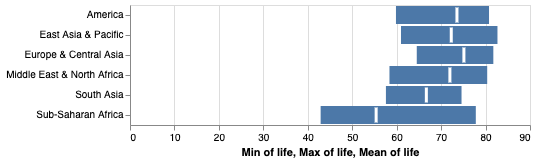

In [ ]:
#creo due chart
base = alt.Chart(df_year).mark_bar().encode(
    x=alt.X('min(life)'),
    x2=alt.X2('max(life)'),
    y=alt.Y('region:N')
).properties(width=400)

average_line= base.mark_tick(color='white', thickness=3).encode(
    x=alt.X('mean(life)'),
    y=alt.Y('region:N')
)
base+average_line

alt.LayerChart(...)

##Esercizio 9
Create a time series on fertility trends for the *Europe & Central Asia* region. Highilight the Italian line

Please Note: To create lines based on the Country attribute without associating it with a specific visual encoder, you can use `detail='Country:N'`


In [ ]:
alt.Chart(df[df['region']== 'Europe & Central Asia']).mark_line( tooltip=True,
    opacity=0.5,
    interpolate='monotone').encode(
        x=alt.X('Year:O'),
        y=alt.Y('fertility:Q'),
        detail='Country:N',
        strokeWidth=alt.condition('datum.Country=="Italy"',alt.StrokeWidthValue(5),alt.StrokeWidthValue(2) ,legend=None),
        color=alt.condition('datum.Country=="Italy"', alt.ColorValue('red'),alt.ColorValue('lightblue') ,legend=None)).properties(
        width={"step": 22}
    )

alt.Chart(...)

another solution

In [ ]:
all_trends=alt.Chart(df[df['region']=='Europe & Central Asia']).mark_line(tooltip=True, interpolate='monotone',opacity=0.8, strokeWidth=0.8).encode(
    x=alt.X('Year:O'),
    y=alt.Y('fertility:Q'),
    detail='Country:N'

)

italy_trend=alt.Chart(df).mark_line(color='red',
                        thickness=3,
                        tooltip=True,
                        interpolate='monotone').encode(
    x=alt.X('Year:O'),
    y=alt.Y('fertility:Q'),
    detail='Country:N'
).transform_filter(
    "datum.Country=='Italy'"
)
all_trends+italy_trend

alt.LayerChart(...)

#Interactivity and Selection

##Esercizio 10a
Create a bubble chart that visualizes on the x-axis the fertility rate and on the y-axis life's expectancy. The size of the bubbles should be related to the population. Visualize the year 2006. The Chart has to be 500px*500px

In [ ]:
alt.Chart(df_year).mark_circle(tooltip=True, filled=True, opacity=0.6).encode(
    x=alt.X('fertility:Q', scale=alt.Scale(zero=False, domain=[0, max(df['fertility'])])),
    y=alt.Y('life:Q', scale=alt.Scale(zero=False, domain=[30, max(df['life'])])),
    size=alt.Size('population:Q', scale=alt.Scale(range=[0,80**2], domain=[0,max(df.population)])),
    color=alt.Color('region:N')
).properties(width=500,height=500).interactive()

alt.Chart(...)

##Exercise 10b
Reproduce the graph above through the small multiples technique (one scatterplot for each *region*)

In [ ]:
alt.Chart(df).transform_filter('datum.Year==2006').mark_circle(filled=True, tooltip=True).encode(
    x=alt.X('fertility:Q', scale=alt.Scale(zero=False, domain=[0, max(df.fertility)])),
    y=alt.Y('life:Q', scale=alt.Scale(zero=False, domain=[20,max(df.life)])),
    size=alt.Size('population:Q', scale=alt.Scale(range=[0,40**2])),
    tooltip= alt.Tooltip(['Country','fertility']),
    color='region:N'
).properties(width=100, height=200).facet(column='region:N')

alt.FacetChart(...)

##Exercise 11
Add a slider to the graph above(10a), so that the user can choose the year

In [ ]:
slider= alt.binding_range(min=min(df.Year), max=max(df.Year), step=1, name='Year:')
select_year= alt.selection_point(fields=['Year'], bind=slider, value=[{'Year':min(df.Year)}])

alt.Chart(df).transform_filter(select_year).mark_circle(tooltip=True, filled=True, opacity=0.6).encode(
    x=alt.X('fertility:Q', scale=alt.Scale(zero=False, domain=[0, max(df['fertility'])])),
    y=alt.Y('life:Q', scale=alt.Scale(zero=False, domain=[30, max(df['life'])])),
    size=alt.Size('population:Q', scale=alt.Scale(range=[0,80**2], domain=[0,max(df.population)])),
    color=alt.Color('region:N')
).properties(width=500,height=500).add_params(select_year).interactive()

##Esercizio 12
Add an horizontal-bar histogram to the 10a an use it as a selector to let the user decide which region to see in the scatterplot.


In [ ]:
click= alt.selection_point(encodings=['color'])

scatterplot = alt.Chart(df).transform_filter('datum.Year==2006').transform_filter(click).mark_circle(filled=True, opacity=0.7).encode(
    x=alt.X('fertility:Q', scale=alt.Scale(zero=False, domain=[0, max(df['fertility'])])),
    y=alt.Y('life:Q', scale=alt.Scale(zero=False, domain=[20, max(df.life)])),
    size=alt.Size('population:Q', scale=alt.Scale(range=[0,80**2], domain=[0,max(df.population)])),
    tooltip=(['Country','fertility','life']),
    color='region:N'
).properties(width=300, height=300).interactive()

histogram= alt.Chart(df_year).transform_aggregate(
    tot_population='sum(population)',
    groupby=['region']
).mark_bar(tooltip=True).encode(
    x='tot_population:Q',
    y=alt.Y('region:N', sort='-x', title=None),
    color='region:N'
).add_params(click)

scatterplot&histogram

##Esercizio 13
Combine the functions of the charts created in ex 11 and 12. Add a text that highlights the position of China and Italy.

In [ ]:
click= alt.selection_point(encodings=['color'])
slider=alt.binding_range(min=min(df.Year), max=max(df.Year), step=1,name='Year: ')
select_year= alt.selection_point(name='year', fields=['Year'], bind=slider, value=[{'Year': min(df.Year)}])

scatter= alt.Chart(
    df).transform_filter(
        select_year
    ).mark_circle(
      filled=True,
      color='lightgrey',
      stroke='black',
      strokeWidth=1,
      clip=True
    ).encode(
        x=alt.X('fertility:Q', scale=alt.Scale(zero=False, domain=[20, max(df.fertility)])),
        y=alt.Y('life:Q', scale=alt.Scale(zero=False, domain=[20, max(df.life)])),
        size=alt.Size('population:Q',scale=alt.Scale(range=[0,80**2], domain=[0,max(df.population)]),legend=alt.Legend(symbolStrokeColor='Black')),
        tooltip= alt.Tooltip(['Country','fertility','life']),
        color=alt.condition(click,'region:N',alt.value(None)),
        stroke=alt.condition(click,alt.value(None),'region:N'),
        strokeWidth=alt.condition(click,alt.value(0),alt.value(1))
        ).properties(
    width=500,
    height=500 )


italy_china= alt.Chart(df).transform_filter(select_year).transform_filter(alt.FieldOneOfPredicate(field='Country', oneOf=['Italy', 'China'])).mark_text(
    fontWeight='bold').encode(text='Country:N',
    x=alt.X('fertility:Q',scale=alt.Scale(zero=False, domain=[0,max(df.fertility)])),
    y=alt.Y(field='life',type='quantitative',scale=alt.Scale(zero=False, domain=[20,max(df.life)])),
).properties(
    width=500,
    height=500
)


hist= alt.Chart(
df
).transform_filter(
    select_year
).transform_aggregate(
    tot_population='sum(population)',
    groupby=["region"]
).mark_bar(
    tooltip=True
).encode(
    x=alt.X('tot_population:Q', scale=alt.Scale(domain=[0,2400000000]), title="Total Population"),
    y=alt.Y('region:N', sort='-x', title=None),
    color=alt.condition(click,'region:N',alt.value('lightgray'), legend=None)
).add_params(
    click
).add_params(
    select_year
).properties(
    width=500
)

(scatter+italy_china) & hist

##OpenLab *selections*

In [ ]:
click = alt.selection_point(encodings=['color'])
slider = alt.binding_range(min=min(df.Year), max=max(df.Year), step=1,name='Year: ')
select_year = alt.selection_point(name="year", fields=['Year'],
                                   bind=slider, value=[{'Year': min(df.Year)}])

interval = alt.selection_interval()

scatter= alt.Chart(
    df
).transform_filter(
    select_year
).mark_circle(
    filled=True,
    color='lightgrey',
    stroke='black',
    strokeWidth=1,
    clip=True
).encode(
    x=alt.X('fertility:Q',scale=alt.Scale(zero=False, domain=[0,max(df.fertility)])),
    y=alt.Y(field='life',type='quantitative',scale=alt.Scale(zero=False, domain=[20,max(df.life)])),
    size=alt.Size('population:Q',scale=alt.Scale(range=[0,80**2], domain=[0,max(df.population)]),legend=alt.Legend(symbolStrokeColor='Black')),
    tooltip= alt.Tooltip(['Country','fertility','life']),
    color=alt.condition(click,'region:N',alt.value(None)),
    stroke=alt.condition(click,alt.value(None),'region:N'),
    strokeWidth=alt.condition(click,alt.value(0),alt.value(1))
).properties(
    width=500,
    height=500
).add_params(
    interval
)


italy= alt.Chart(
    df
).transform_filter(
    select_year
).transform_filter(
   alt.FieldOneOfPredicate(field='Country', oneOf=['Italy', 'China'])
).mark_text(
    fontWeight='bold'
).encode(
    text='Country:N',
    x=alt.X('fertility:Q',scale=alt.Scale(zero=False, domain=[0,max(df.fertility)])),
    y=alt.Y(field='life',type='quantitative',scale=alt.Scale(zero=False, domain=[20,max(df.life)])),
).properties(
    width=500,
    height=500
)

hist = alt.Chart(
df
).transform_filter(
    select_year
).transform_filter(
    interval
).transform_aggregate(
    tot_population='sum(population)',
    groupby=["region"]
).mark_bar(
    tooltip=True
).encode(
    x=alt.X('tot_population:Q', scale=alt.Scale(domain=[0,2400000000]), title="Total Population"),
    y=alt.Y('region:N', sort='-x', title=None),
    color=alt.condition(click,'region:N',alt.value('lightgray'), legend=None)
).add_params(
    click
).add_params(
    select_year
).properties(
    width=500
)

(scatter+italy) & hist